## Rapport du projet :

## importer les donnes :

In [10]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")
df.head()

,rank,name,year,rating,genre,certificate,run_time,tagline,budget,box_office,casts,directors,writers
0,1,The Shawshank Redemption,1994,9.3,Drama,R,2h 22m,Fear can hold you prisoner. Hope can set you f...,25000000,28884504,"Tim Robbins,Morgan Freeman,Bob Gunton,William ...",Frank Darabont,"Stephen King,Frank Darabont"
1,2,The Godfather,1972,9.2,"Crime,Drama",R,2h 55m,An offer you can't refuse.,6000000,250341816,"Marlon Brando,Al Pacino,James Caan,Diane Keato...",Francis Ford Coppola,"Mario Puzo,Francis Ford Coppola"
2,3,The Dark Knight,2008,9.0,"Action,Crime,Drama",PG-13,2h 32m,Why So Serious?,185000000,1006234167,"Christian Bale,Heath Ledger,Aaron Eckhart,Mich...",Christopher Nolan,"Jonathan Nolan,Christopher Nolan,David S. Goyer"
3,4,The Godfather Part II,1974,9.0,"Crime,Drama",R,3h 22m,All the power on earth can't change destiny.,13000000,47961919,"Al Pacino,Robert De Niro,Robert Duvall,Diane K...",Francis Ford Coppola,"Francis Ford Coppola,Mario Puzo"
4,5,12 Angry Men,1957,9.0,"Crime,Drama",Approved,1h 36m,Life Is In Their Hands -- Death Is On Their Mi...,350000,955,"Henry Fonda,Lee J. Cobb,Martin Balsam,John Fie...",Sidney Lumet,Reginald Rose


### Data infos:

In [12]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")

print(df.head())
print(df.info())

   rank                      name  year  rating               genre  \
0     1  The Shawshank Redemption  1994     9.3               Drama   
1     2             The Godfather  1972     9.2         Crime,Drama   
2     3           The Dark Knight  2008     9.0  Action,Crime,Drama   
3     4     The Godfather Part II  1974     9.0         Crime,Drama   
4     5              12 Angry Men  1957     9.0         Crime,Drama   

  certificate run_time                                            tagline  \
0           R   2h 22m  Fear can hold you prisoner. Hope can set you f...   
1           R   2h 55m                         An offer you can't refuse.   
2       PG-13   2h 32m                                    Why So Serious?   
3           R   3h 22m       All the power on earth can't change destiny.   
4    Approved   1h 36m  Life Is In Their Hands -- Death Is On Their Mi...   

      budget  box_office                                              casts  \
0   25000000    28884504  Tim R

### supprimer les valeurs doublons :

In [15]:
df = df.drop_duplicates(subset="name")

### Verifier les valeurs manquantes :

In [2]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")
print(df.isnull().sum())

rank           0
name           0
year           0
rating         0
genre          0
certificate    0
run_time       0
tagline        0
budget         0
box_office     0
casts          0
directors      0
writers        0
dtype: int64


#### donc les donnes ne contient pas des valeurs nulls

## NETTOYER la colonne Year :

In [3]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")

df["year"] = df["year"].astype(str).str.extract(r'(\d{4})')
df["year"] = pd.to_numeric(df["year"])

## Nettoyer run_time

In [5]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")

df["run_time"] = df["run_time"].str.replace(" min","")
df["run_time"] = pd.to_numeric(df["run_time"], errors="coerce")

## Nettoyer budget et box_office

In [6]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")

df["budget"] = df["budget"].str.replace("$","", regex=False)
df["budget"] = df["budget"].str.replace(",","")
df["budget"] = pd.to_numeric(df["budget"], errors="coerce")

df["box_office"] = df["box_office"].str.replace("$","", regex=False)
df["box_office"] = df["box_office"].str.replace(",","")
df["box_office"] = pd.to_numeric(df["box_office"], errors="coerce")

## telecharger le nouveau fichier csv nettoyer :

In [8]:
import pandas as pd

df = pd.read_csv("../data/IMDB Top 250 Movies.csv")
df.to_csv("movies_clean.csv", index=False)

----------------------------------------------------------------------------------------------------------------

### Statistique interessante :

#### Top 10 films par rating:

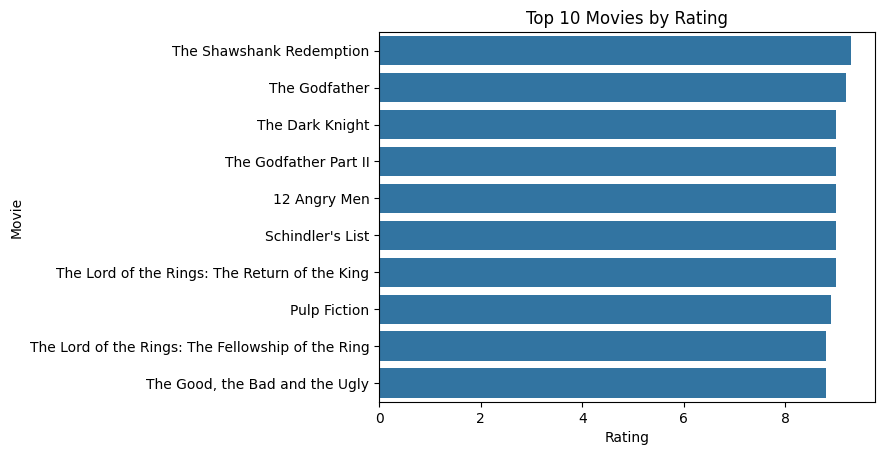

                                                name  rating
0                           The Shawshank Redemption     9.3
1                                      The Godfather     9.2
2                                    The Dark Knight     9.0
3                              The Godfather Part II     9.0
4                                       12 Angry Men     9.0
5                                   Schindler's List     9.0
6      The Lord of the Rings: The Return of the King     9.0
7                                       Pulp Fiction     8.9
8  The Lord of the Rings: The Fellowship of the Ring     8.8
9                     The Good, the Bad and the Ugly     8.8


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
top_rating = df.sort_values("rating", ascending=False).head(10)

plt.figure()
sns.barplot(x="rating", y="name", data=top_rating)
plt.title("Top 10 Movies by Rating")
plt.xlabel("Rating")
plt.ylabel("Movie")
plt.show()

print(top_rating[["name","rating"]])

#### Les 10 acteurs les plus présents et les plus participer :

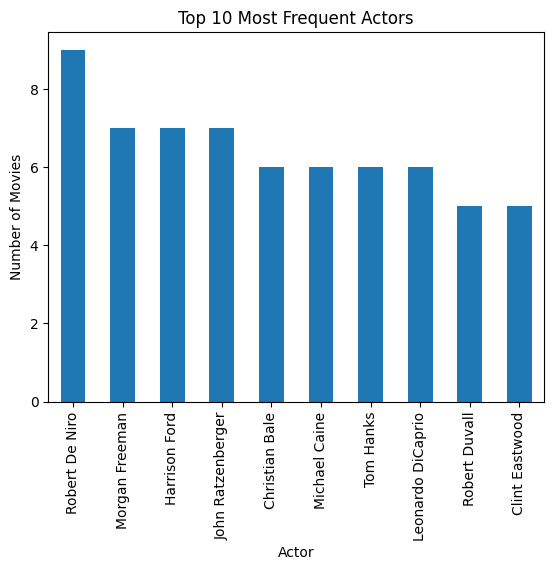

Robert De Niro       9
Morgan Freeman       7
Harrison Ford        7
John Ratzenberger    7
Christian Bale       6
Michael Caine        6
Tom Hanks            6
Leonardo DiCaprio    6
Robert Duvall        5
Clint Eastwood       5
Name: count, dtype: int64


In [12]:
actors = df["casts"].dropna().str.split(",")

actor_list = []

for a in actors:
    for actor in a:
        actor_list.append(actor.strip())

actor_series = pd.Series(actor_list)

top_actors = actor_series.value_counts().head(10)

plt.figure()
top_actors.plot(kind="bar")
plt.title("Top 10 Most Frequent Actors")
plt.xlabel("Actor")
plt.ylabel("Number of Movies")
plt.show()

print(top_actors)

#### Durée des films (min et max):

Longest movie duration: Not Available
Shortest movie duration: 1h 20m


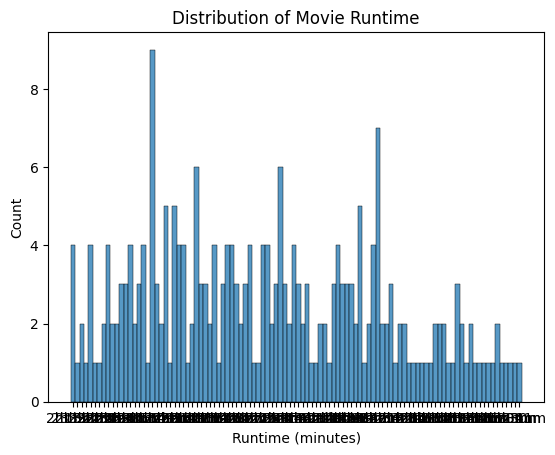

In [19]:
max_runtime = df["run_time"].max()
min_runtime = df["run_time"].min()

print("Longest movie duration:", max_runtime)
print("Shortest movie duration:", min_runtime)

plt.figure()
sns.histplot(df["run_time"], bins=20)
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.show()

#### Top 10 Box Office:

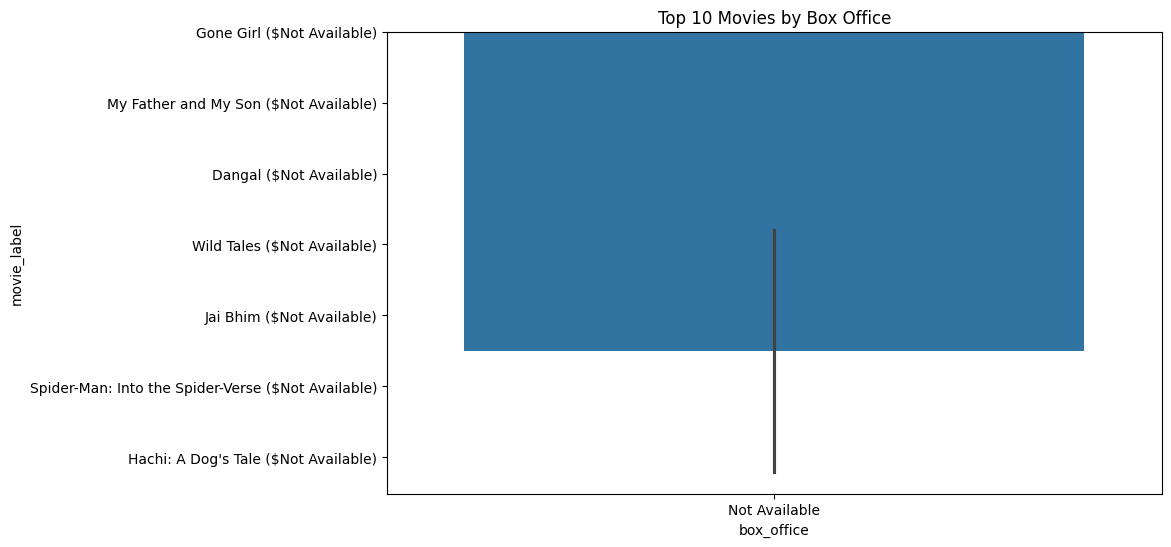

In [25]:
top_box = df.sort_values("box_office", ascending=False).head(10)

top_box["movie_label"] = top_box["name"] + " ($" + top_box["box_office"].astype(str) + ")"

plt.figure(figsize=(10,6))

sns.barplot(
    x="box_office",
    y="movie_label",
    data=top_box
)

plt.title("Top 10 Movies by Box Office")

plt.show()

#### Sauvegarder DataSet :

In [27]:
df.to_csv("movies_final.csv", index=False)

#### Transformer le dataset en base de données:

Les sites web ne lisent pas directement un CSV.
On convertit les données vers une base SQL.

In [28]:
import sqlite3

conn = sqlite3.connect("movies.db")

df.to_sql("movies", conn, if_exists="replace", index=False)

conn.close()